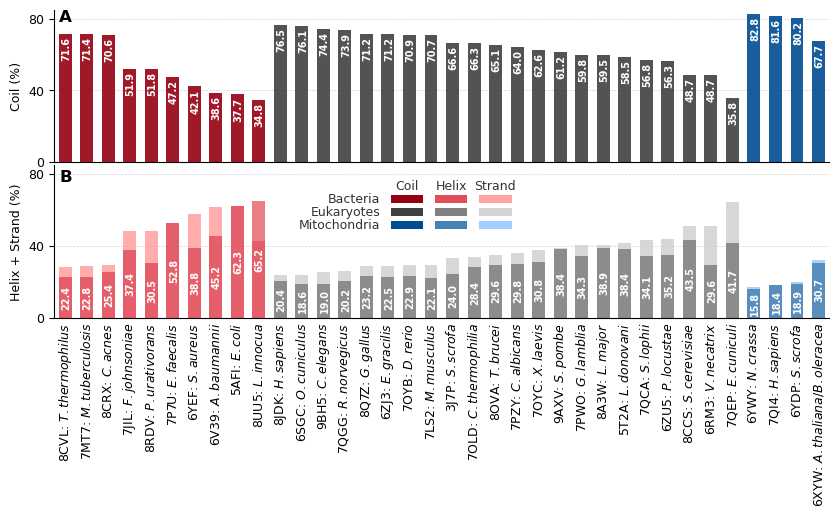

In [1]:
import os
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib
from collections import Counter

matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams["font.family"] = "sans-serif"

BASE_DIR = ".."
RESULTS_DSSP_DIR = f"{BASE_DIR}/RESULTS_DSSP"
PLOT_DIR = f"{BASE_DIR}/PLOTS"

MIN_LENGTH = 20

SS_GROUPS = {
    "Helix": {"H", "G", "I"},
    "Strand": {"E", "B"},
    "Coil": {"C", "-", " "},
}

COLOR_MAP = {
    "bacteria": {
        "Coil": "#960012",
        "Helix": "#E14D59",
        "Strand": "#FFA4A4",
    },
    "eukaryotes": {
        "Coil": "#404040",
        "Helix": "#808080",
        "Strand": "#D3D3D3",
    },
    "mitochondria": {
        "Coil": "#004B93",
        "Helix": "#4682B4",
        "Strand": "#A0CFFF",
    }
}

AA_3TO1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "SEC": "U", "PYL": "O",
}

def map_ss(code):
    for group, members in SS_GROUPS.items():
        if code in members:
            return group
    return "Coil"

def load_dssp(pdb_id, chain_id):
    path = os.path.join(RESULTS_DSSP_DIR, pdb_id, f"{chain_id}.csv")
    if not os.path.exists(path):
        return [], [], []
    residue_numbers = []
    residue_seq = []
    ss_codes = []
    with open(path) as f:
        for row in csv.DictReader(f):
            one_letter = AA_3TO1.get(row["residue_name"].upper())
            if one_letter is None:
                continue
            residue_numbers.append(int(row["residue_number"]))
            residue_seq.append(one_letter)
            ss_codes.append(row["secondary_structure"])
    return residue_numbers, residue_seq, ss_codes

def find_fragment_in_chain(fpf_sequence, residue_seq):
    chain_str = "".join(residue_seq)
    return chain_str.find(fpf_sequence)

def collect_fpf_ss(pdb_id, fpf_fragments):
    chain_cache = {}
    all_codes = []
    chains_with_data = set()

    for frag in fpf_fragments:
        chain_id = frag["chain_name"]
        fpf_seq = frag["sequence"]

        if chain_id not in chain_cache:
            chain_cache[chain_id] = load_dssp(pdb_id, chain_id)
        residue_numbers, residue_seq, ss_codes = chain_cache[chain_id]

        start_idx = find_fragment_in_chain(fpf_seq, residue_seq)

        frag_ss = ss_codes[start_idx : start_idx + len(fpf_seq)]
        all_codes.extend([map_ss(code) for code in frag_ss])
        chains_with_data.add(chain_id)

    return all_codes, len(chains_with_data)

with open(os.path.join(BASE_DIR, "ribosome_info.json")) as f:
    ribosome_info = json.load(f)

with open(os.path.join(BASE_DIR, "fpf_info.json")) as f:
    fpf_info = json.load(f)

data = []
for entry in ribosome_info:
    pdb_id = entry["pdb_id"].upper()
    ribosome_class = entry["ribosome_class"].lower()

    fragments = fpf_info.get(pdb_id, [])
    fragments = [f for f in fragments if f["length"] >= MIN_LENGTH]
    if not fragments:
        continue

    codes, n_chains = collect_fpf_ss(pdb_id, fragments)
    if not codes:
        continue

    counts = Counter(codes)
    total = sum(counts.values())
    pcts = {ss: (counts.get(ss, 0) / total * 100) for ss in ["Coil", "Helix", "Strand"]}
    data.append({
        "pdb_id": pdb_id,
        "organism": entry["organism"],
        "domain": ribosome_class,
        "percentages": pcts,
    })

domain_order = ["bacteria", "eukaryotes", "mitochondria"]
data.sort(
    key=lambda x: (
        domain_order.index(x["domain"]) if x["domain"] in domain_order else 99,
        -x["percentages"]["Coil"],
    )
)

labels = [f"{d['pdb_id']}: $\\mathit{{{d['organism']}}}$" for d in data]
coil_pcts = [d["percentages"]["Coil"] for d in data]
helix_pcts = [d["percentages"]["Helix"] for d in data]
strand_pcts = [d["percentages"]["Strand"] for d in data]

coil_colors = [COLOR_MAP.get(d["domain"], COLOR_MAP["eukaryotes"])["Coil"] for d in data]
helix_colors = [COLOR_MAP.get(d["domain"], COLOR_MAP["eukaryotes"])["Helix"] for d in data]
strand_colors = [COLOR_MAP.get(d["domain"], COLOR_MAP["eukaryotes"])["Strand"] for d in data]

n = len(data)
x = np.arange(n)
fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.02)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
bars_coil = ax_top.bar(x, coil_pcts, width=0.6, color=coil_colors, alpha=0.9, zorder=2)
for bar, val, col in zip(bars_coil, coil_pcts, coil_colors):
    if val > 4.0:
        ax_top.text(bar.get_x() + bar.get_width() / 2 + 0.05, bar.get_height() - 1.5, f"{val:.1f}", va="top", ha="center", color="white", fontsize=7, fontweight="bold", rotation=90)
ax_top.set_ylabel("Coil (%)")
ax_top.set_ylim(0, 85)
ax_top.set_yticks([0, 40, 80])
ax_top.set_xlim(-0.5, n - 0.5)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.tick_params(axis="x", length=0)
plt.setp(ax_top.get_xticklabels(), visible=False)
ax_top.yaxis.grid(True, linestyle="--", linewidth=0.5, color="lightgray", zorder=0)
ax_top.set_axisbelow(True)
bars_helix = ax_bot.bar(x, helix_pcts, width=0.6, color=helix_colors, alpha=0.9, zorder=2)
bars_strand = ax_bot.bar(x, strand_pcts, bottom=helix_pcts, width=0.6, color=strand_colors, alpha=0.9, zorder=2)
for bar, val, col in zip(bars_helix, helix_pcts, helix_colors):
    if val > 9.0:
        ax_bot.text(bar.get_x() + bar.get_width() / 2 + 0.05, bar.get_height() / 2, f"{val:.1f}", va="center", ha="center", color="white", fontsize=7, fontweight="bold", rotation=90)
ax_bot.set_ylabel("Helix + Strand (%)")
ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)
ax_bot.tick_params(axis="x", length=0)
ax_bot.set_ylim(0, 85)
ax_bot.set_yticks([0, 40, 80])
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(labels, rotation=90)
ax_bot.yaxis.grid(True, linestyle="--", linewidth=0.5, color="lightgray", zorder=0)
ax_bot.set_axisbelow(True)

ax_leg = ax_bot.inset_axes([0.25, 0.5, 0.38, 0.48])
ax_leg.set_facecolor("white")
ax_leg.patch.set_alpha(0.2)
for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_color("none")
    spine.set_linewidth(0.8)
ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)

headers = ["Coil", "Helix", "Strand"]
col_x = [0.54, 0.69, 0.84]
for h, x_pos in zip(headers, col_x):
    ax_leg.text(x_pos, 0.75, h, ha="center", va="center", color="#333333")

rows = [
    ("Bacteria", "bacteria"),
    ("Eukaryotes", "eukaryotes"),
    ("Mitochondria", "mitochondria")
]
row_y = [0.58, 0.40, 0.22]
for (r_display, r_key), y_pos in zip(rows, row_y):
    ax_leg.text(0.45, y_pos, r_display, ha="right", va="center", color="#333333")
    for ss_name, x_pos in zip(["Coil", "Helix", "Strand"], col_x):
        color = COLOR_MAP[r_key][ss_name]
        rect = mpatches.Rectangle(
            (x_pos - 0.055, y_pos - 0.055),
            0.11, 0.11,
            facecolor=color,
            edgecolor="none"
        )
        ax_leg.add_patch(rect)

fig.text(0.13, 0.85, "A", fontweight="bold", fontsize=12)
fig.text(0.13, 0.45, "B", fontweight="bold", fontsize=12)
plt.savefig(f"{PLOT_DIR}/dssp.png", dpi=300, bbox_inches="tight")